In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import torch
import torch.nn as nn
from torch.nn import functional as F
import math
from torch.nn import LayerNorm

In [3]:
from kret_studies import *
from kret_studies.notebook import *
from kret_studies.complex import *

Loaded environment variables from /Users/Akseldkw/Desktop/Columbia/COMS4776/.env.


INFO:datasets:JAX version 0.7.2 available.


In [4]:
from kret_studies.kret_torch.mixin.constants import DEVICE_TORCH_STR, DEVICE_LITERAL

device: DEVICE_LITERAL = DEVICE_TORCH_STR
NUM_EPOCHS = 25

In [5]:
from trainer import save_model_auto, load_model_auto, model_filename

In [6]:
# !pip install thop
# !pip install tdqm

# Part 1: Attention and Encoder-Decoder Models

In this section, you'll implement two forms of attention and use them in an encoder-decoder style transformer. You'll then compare performance based on changing dataset size and hidden dimension.

## Step 1: Scaled Dot Product Attention
Implement both the base `scaled_dot_attention` method as well as the `forward` method for the `Attention` module.

In [7]:
def scaled_dot_attention(
    q: torch.Tensor, k: torch.Tensor, v: torch.Tensor, mask: torch.Tensor | None = None
):
    """Computes scaled dot product attention with an optional mask.
      q : shape ( batch, k, hidden_size)
      k : shape ( batch, seq_len, hidden_size)
      v : shape ( batch, seq_len, hidden_size)
      mask: optional. shape (k, seq_len)

    returns:
        context   : shape (batch, k, hidden_size)
        attention : shape (batch, k, seq_len)
    """

    # ------------
    # FILL THIS IN
    # ------------
    unnorm_attn = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(q.size(-1))
    if mask is not None:
        unnorm_attn = unnorm_attn.masked_fill(mask == 0, float("-inf"))
    attention = F.softmax(unnorm_attn, dim=-1)
    context = torch.matmul(attention, v)
    return context, attention

In [8]:
class Attention(nn.Module):
    def __init__(self, hidden_size: int):
        super().__init__()
        self.Q = nn.Linear(hidden_size, hidden_size, bias=False)
        self.K = nn.Linear(hidden_size, hidden_size, bias=False)
        self.V = nn.Linear(hidden_size, hidden_size, bias=False)
        self.hidden_size = hidden_size
        self.to(device)
        self.filename = model_filename(hidden_size=hidden_size)

    def forward(self, x: torch.Tensor, annots: torch.Tensor):
        #   x         : shape ( batch, k, hidden_size)
        #   annots    : shape ( batch, seq_len, hidden_size)

        # ------------
        # FILL THIS IN
        # Pay attention to which inputs you use for the queries, keys, and values.
        # ------------
        # q =
        # k =
        # v =
        q = self.Q(x)
        k = self.K(annots)
        v = self.V(annots)
        return scaled_dot_attention(q, k, v)

## Step 2: Causal Scaled Dot Product Attention
Using your `scaled_dot_attention` method, implement the `forward` method for the `CausalAttention` module.


In [9]:
class CausalAttention(Attention):
    def __init__(self, hidden_size: int):
        super().__init__(hidden_size)
        self.to(device)
        self.filename = model_filename(hidden_size=hidden_size)

    def forward(self, x: torch.Tensor):
        #   x : shape ( batch, seq_len, hidden_size)

        # ------------
        # FILL THIS IN
        # This should be very similar to your other attention implementation,
        # with the exception that you only have one set of outputs and you
        # must construct a causal attention mask.
        # ------------
        # q =
        # k =
        # v =
        # mask =
        seq_len = x.size(1)
        q = self.Q(x)
        k = self.K(x)
        v = self.V(x)
        mask = torch.tril(torch.ones((seq_len, seq_len), device=x.device)).bool()
        return scaled_dot_attention(q, k, v, mask)

#### Simple test cases
##### Passing this DOES NOT mean your implementation is correct. But, if this fails, then you definitely did something wrong

In [10]:
cros_attn = Attention(32)
caus_attn = CausalAttention(32)
caus_attn.Q = cros_attn.Q
caus_attn.K = cros_attn.K
caus_attn.V = cros_attn.V

inp = torch.randn(4, 8, 32).to(device)
inp2 = torch.randn(4, 16, 32).to(device)

print("Checking consistent shape")
assert cros_attn(inp, inp2)[0].shape == inp.shape
assert caus_attn(inp)[0].shape == inp.shape
assert cros_attn(inp, inp2)[1].shape == (4, 8, 16)
assert caus_attn(inp)[1].shape == (4, 8, 8)

print("Checking attention mask")
assert torch.all(caus_attn(inp)[0][:, -1] == cros_attn(inp, inp)[0][:, -1])

print("Passed")

Checking consistent shape
Checking attention mask
Passed


#### Read through the following code. Make sure you understand what is going on.
This code sets up the encoder-decoder architecture. It requires no additional code.

In [11]:
class PositionalEncoding(nn.Module):
    pe: torch.Tensor

    def __init__(self, hidden_size: int, max_len: int = 1000):
        super().__init__()

        pos = torch.arange(max_len).float().unsqueeze(1)
        dim = torch.arange(hidden_size // 2).float().unsqueeze(0)

        div_term = torch.exp(-math.log(10000.0) * (2 * dim) / hidden_size)
        angle = pos * div_term

        pe = torch.zeros(max_len, hidden_size)
        pe[:, 0::2] = torch.sin(angle)
        pe[:, 1::2] = torch.cos(angle)

        self.register_buffer("pe", pe)
        self.to(device)
        self.filename = model_filename(hidden_size=hidden_size, max_len=max_len)

    def forward(self, idx: int):
        return self.pe[idx]

In [12]:
class MLP(nn.Module):

    def __init__(self, hidden_size: int):
        super().__init__()
        self.layer1 = nn.Linear(hidden_size, hidden_size, bias=False)
        self.layer2 = nn.Linear(hidden_size, hidden_size, bias=False)
        self.relu = nn.ReLU()
        self.to(device)
        self.filename = model_filename(hidden_size=hidden_size)

    def forward(self, x: torch.Tensor):
        x = self.layer1(x)
        x = self.relu(x)
        x = self.layer2(x)
        return x


class EncoderBlock(nn.Module):
    def __init__(self, hidden_size: int):
        super().__init__()
        self.norm1 = LayerNorm(hidden_size)
        self.norm2 = LayerNorm(hidden_size)
        self.attn = Attention(hidden_size)
        self.mlp = MLP(hidden_size)
        self.to(device)
        self.filename = model_filename(hidden_size=hidden_size)

    def forward(self, x: torch.Tensor):
        context, attention = self.attn(self.norm1(x), self.norm1(x))
        x = x + context
        x = x + self.mlp(self.norm2(x))
        return x, attention


class DecoderBlock(nn.Module):
    def __init__(self, hidden_size: int):
        super().__init__()
        self.norm1 = LayerNorm(hidden_size)
        self.norm2 = LayerNorm(hidden_size)
        self.cros_attn = Attention(hidden_size)
        self.self_attn = CausalAttention(hidden_size)
        self.mlp = MLP(hidden_size)
        self.to(device)
        self.filename = model_filename(hidden_size=hidden_size)

    def forward(self, x: torch.Tensor, annotation: torch.Tensor):
        context, self_attn = self.self_attn(self.norm1(x))
        x = x + context
        context, cros_attn = self.cros_attn(self.norm2(x), annotation)
        x = x + context
        x = x + self.mlp(self.norm2(x))
        return x, self_attn, cros_attn

In [13]:
class TransformerEncoderDecoder(nn.Module):
    def __init__(
        self, vocab_size: int, hidden_size: int, num_layers: int, dataset_name: str
    ):
        super().__init__()

        self.tok_emb = nn.Embedding(vocab_size, hidden_size)
        self.pos_emb = PositionalEncoding(hidden_size)

        self.encoder_blocks = nn.ModuleList(
            [EncoderBlock(hidden_size) for i in range(num_layers)]
        )
        self.decoder_blocks = nn.ModuleList(
            [DecoderBlock(hidden_size) for i in range(num_layers)]
        )

        self.head = nn.Linear(hidden_size, vocab_size, bias=False)
        self.head.weight = self.tok_emb.weight
        # weight tie, the final layer reuses the weights of the embedding layers
        # this reduces the total number of parameters

        self.apply(self._init_weights)  # initialize the weights to a small number
        self.to(device)
        self.filename = model_filename(
            hidden_size=hidden_size,
            num_layers=num_layers,
            vocab_size=vocab_size,
            dataset_name=dataset_name,
        )

    def forward(self, inputs: torch.Tensor, annots: torch.Tensor):

        pos_x = torch.arange(
            0, inputs.shape[-1], device=inputs.device
        ).long()  # creates tensor([0, 1, 2, 3, ...])
        pos_y = torch.arange(
            0, annots.shape[-1], device=inputs.device
        ).long()  # creates tensor([0, 1, 2, 3, ...])

        x = self.tok_emb(inputs) + self.pos_emb(pos_x)
        y = self.tok_emb(annots) + self.pos_emb(pos_y)

        self_attn = []
        cros_attn = []

        for encode in self.encoder_blocks:
            y, _ = encode(y)

        for decode in self.decoder_blocks:
            x, s, c = decode(x, y)
            cros_attn.append(c)
            self_attn.append(s)

        return self.head(x), {"self_attn": self_attn, "cros_attn": cros_attn}

    def _init_weights(self, module: torch.nn.Module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

## Step 3: Training the model

You'll now train a set of example models. This section requires no additional code from you, with the exception of setting the datapath. However, **you are required to analyze and include some of its output**.

In [14]:
from dataset import EncoderDecoderDataset, DecoderDataset
from utils import save_loss_comparison_by_dataset, save_loss_comparison_by_hidden
from torch.utils.data import DataLoader
from trainer import train
import torch.optim as optim


data_path = str("./")  # Change data_path to where the data is stored

encdec_ds_small = EncoderDecoderDataset(data_path, "pig_latin_small")
encdec_ds_large = EncoderDecoderDataset(data_path, "pig_latin_large")

In [15]:
print("Dataset sample:")
print("Input:", encdec_ds_small.to_token(encdec_ds_small[0][0].tolist()))
print("Annotation:", encdec_ds_small.to_token(encdec_ds_small[0][1].tolist()))
print("Target:", encdec_ds_small.to_token(encdec_ds_small[0][2].tolist()))

Dataset sample:
Input: <SOS>econcileray
Annotation: reconcile
Target: econcileray<EOS>


In [16]:
model = load_model_auto(
    TransformerEncoderDecoder,
    vocab_size=len(encdec_ds_small.idx_to_token),
    hidden_size=16,
    num_layers=4,
    dataset_name="small",
)

[INFO] Loading model weights from /Users/Akseldkw/coding/Columbia/COMS4776-Data/data/homework/HW2/TransformerEncoderDecoder/Model_ds_namesmall_vocab30_hid16_layers4.pt onto mps device.


In [17]:
optimizer = optim.AdamW(model.parameters(), lr=1e-2)
scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.95)

results = train(
    model=model,
    dataset=encdec_ds_small,
    num_epochs=NUM_EPOCHS,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    batch_size=32,
)
save_model_auto(model)

Epoch 1 | Train loss: 1.551056 | Val loss 1.326135
Epoch 2 | Train loss: 1.063675 | Val loss 0.810254
Epoch 3 | Train loss: 0.601667 | Val loss 0.450644
Epoch 4 | Train loss: 0.395058 | Val loss 0.329814
Epoch 5 | Train loss: 0.339731 | Val loss 0.281942
Epoch 6 | Train loss: 0.242083 | Val loss 0.251930
Epoch 7 | Train loss: 0.201196 | Val loss 0.201325
Epoch 8 | Train loss: 0.165927 | Val loss 0.269903
Epoch 9 | Train loss: 0.156907 | Val loss 0.116667
Epoch 10 | Train loss: 0.119682 | Val loss 0.132721
Epoch 11 | Train loss: 0.111152 | Val loss 0.135230
Epoch 12 | Train loss: 0.096481 | Val loss 0.094605
Epoch 13 | Train loss: 0.089595 | Val loss 0.114751
Epoch 14 | Train loss: 0.087959 | Val loss 0.094765
Epoch 15 | Train loss: 0.077084 | Val loss 0.104997
Epoch 16 | Train loss: 0.061116 | Val loss 0.074258
Epoch 17 | Train loss: 0.064619 | Val loss 0.081565
Epoch 18 | Train loss: 0.063316 | Val loss 0.081086
Epoch 19 | Train loss: 0.045618 | Val loss 0.072637
Epoch 20 | Train loss

PosixPath('/Users/Akseldkw/coding/Columbia/COMS4776-Data/data/homework/HW2/TransformerEncoderDecoder/Model_ds_namesmall_vocab30_hid16_layers4.pt')

In [18]:
def encdec_generate(
    input: str,
    model: TransformerEncoderDecoder,
    dataset: EncoderDecoderDataset,
    max_len: int = 20,
):
    gen_string = ""
    idx = torch.tensor([[dataset.start_idx]]).to(device)
    annots = torch.tensor(
        [dataset.to_idx(input) + [dataset.end_idx] * (max(0, 12 - len(input)))]
    ).to(device)
    # pad the input string with <EOS> since the collate_fn had to pad the stirngs

    for i in range(max_len):
        logits = model(idx, annots)[0]

        token_idx: torch.Tensor = logits[0, -1:].argmax(dim=-1)
        idx = torch.cat([idx, token_idx.unsqueeze(0)], dim=1)

        if token_idx.item() == dataset.end_idx:
            break
        else:
            gen_string = gen_string + dataset.idx_to_token[int(token_idx.item())]
    return gen_string


def encdec_translate(
    sentence: str, model: TransformerEncoderDecoder, dataset: EncoderDecoderDataset
):
    words = sentence.split()
    return " ".join([encdec_generate(w, model, dataset) for w in words])

In [19]:
encdec_translate("the", model, encdec_ds_small)

'ethay'

In [20]:
encdec_translate("the air conditioning is working", model, encdec_ds_small)

'ethay airway onditioningcay isway orkingway'

In [21]:
encdec_translate("testing some random words", model, encdec_ds_small)

'estingtay omesay andomray ordsway'

In [22]:
configs = [
    (16, "small", encdec_ds_small),
    (16, "large", encdec_ds_large),
    (32, "small", encdec_ds_small),
    (32, "large", encdec_ds_large),
]

all_results = {}

for hidden_size, dataset_name, dataset in configs:
    print(f"\nTraining model: hidden_size={hidden_size}, dataset={dataset_name}")

    model = load_model_auto(
        TransformerEncoderDecoder,
        vocab_size=len(dataset.idx_to_token),
        hidden_size=hidden_size,
        num_layers=4,
        dataset_name=dataset_name,
    )

    optimizer = optim.AdamW(model.parameters(), lr=1e-2)
    scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.95)

    results = train(
        model=model,
        dataset=dataset,
        num_epochs=NUM_EPOCHS,
        optimizer=optimizer,
        scheduler=scheduler,
        device=device,
        batch_size=32 if dataset_name == "small" else 256,
    )
    all_results[(hidden_size, dataset_name)] = results
    save_model_auto(model)

save_loss_comparison_by_dataset(all_results)
save_loss_comparison_by_hidden(all_results)


Training model: hidden_size=16, dataset=small
[INFO] Loading model weights from /Users/Akseldkw/coding/Columbia/COMS4776-Data/data/homework/HW2/TransformerEncoderDecoder/Model_ds_namesmall_vocab30_hid16_layers4.pt onto mps device.
Epoch 1 | Train loss: 0.282690 | Val loss 0.119487
Epoch 2 | Train loss: 0.100203 | Val loss 0.125501
Epoch 3 | Train loss: 0.096975 | Val loss 0.092090
Epoch 4 | Train loss: 0.078260 | Val loss 0.084708
Epoch 5 | Train loss: 0.072440 | Val loss 0.088962
Epoch 6 | Train loss: 0.066571 | Val loss 0.072962
Epoch 7 | Train loss: 0.065810 | Val loss 0.065583
Epoch 8 | Train loss: 0.054039 | Val loss 0.067781
Epoch 9 | Train loss: 0.052774 | Val loss 0.079471
Epoch 10 | Train loss: 0.061673 | Val loss 0.069800
Epoch 11 | Train loss: 0.046289 | Val loss 0.075188
Epoch 12 | Train loss: 0.043467 | Val loss 0.048739
Epoch 13 | Train loss: 0.036280 | Val loss 0.044235
Epoch 14 | Train loss: 0.030028 | Val loss 0.040429
Epoch 15 | Train loss: 0.024368 | Val loss 0.0452

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

# Part 2: Decoder-only Transformers and Multi-Head Attention

In this section, you'll train transformers that only use a decoder instead of a dual encoder-decoder architecture. You'll also implement and experiment with multi-head attention. Finally, you'll compare increasing parameter count with multi-head attention vs. increasing the parameter count with a larger hidden dimensionality.

## Step 1: Implement the Decoder-Only Forward Method

In [23]:
class DecoderOnlyBlock(nn.Module):
    def __init__(self, hidden_size: int):
        super().__init__()
        self.norm1 = LayerNorm(hidden_size)
        self.norm2 = LayerNorm(hidden_size)
        self.attn = CausalAttention(hidden_size)
        self.mlp = MLP(hidden_size)
        self.to(device)
        self.filename = model_filename(hidden_size=hidden_size)

    def forward(self, x: torch.Tensor):
        context, attention = self.attn(self.norm1(x))
        x = x + context
        x = x + self.mlp(self.norm2(x))
        return x, attention


class DecoderTransformer(nn.Module):
    def __init__(self, vocab_size: int, hidden_size: int, num_layers: int):
        super().__init__()

        self.tok_emb = nn.Embedding(vocab_size, hidden_size)
        self.pos_emb = PositionalEncoding(hidden_size)

        self.blocks = nn.ModuleList(
            [DecoderOnlyBlock(hidden_size) for i in range(num_layers)]
        )
        self.head = nn.Linear(hidden_size, vocab_size, bias=False)
        self.head.weight = self.tok_emb.weight
        # weight tie, the final layer reuses the weights of the embedding layers
        # this reduces the total number of parameters
        self.to(device)
        self.filename = model_filename(
            hidden_size=hidden_size, num_layers=num_layers, vocab_size=vocab_size
        )

    def forward(self, inputs: torch.Tensor):
        """Forward pass of the Transformer decoder.

        Arguments:
            inputs: Input token indexes across a batch for all the time step. (batch_size x decoder_seq_len)
        Returns:
            output: Un-normalized scores for each token in the vocabulary, across a batch for all the decoding time steps. (batch_size x decoder_seq_len x vocab_size)
            attentions: The stacked attention weights applied to the encoder annotations (batch_size x encoder_seq_len x decoder_seq_len)
        """
        # ------------
        # FILL THIS IN
        # ------------
        # pos =
        # x =
        # self_attn = []

        # for block in self.blocks:
        #     ...
        #
        # unormalized_scores =
        pos = torch.arange(0, inputs.shape[-1], device=inputs.device).long()
        x = self.tok_emb(inputs) + self.pos_emb(pos)
        self_attn = []
        for block in self.blocks:
            x, s = block(x)
            self_attn.append(s)
        unormalized_scores = self.head(x)

        return unormalized_scores, {"self_attn": self_attn}

In [24]:
decoder_ds_small = DecoderDataset(data_path, "pig_latin_small")
decoder_ds_large = DecoderDataset(data_path, "pig_latin_large")

In [25]:
print("Dataset sample:")
print("Input:", decoder_ds_small.to_token(decoder_ds_small[0][0].tolist()))
print("Target:", decoder_ds_small.to_token(decoder_ds_small[0][1].tolist()))

Dataset sample:
Input: <SOS>reconcile<EOP>econcileray
Target: reconcile<EOP>econcileray<EOS>


## Step 2: Format for decoder-only generation.

Implement the missing line in `decoder_generate` to create an input string that looks like:

```
<SOS> input sequence <EOP>
```
You should use the `dataset.start_idx`, `dataset.eop_idx` attributes and the `dataset.to_idx()` method.

In [26]:
def decoder_generate(
    input: str,
    model: DecoderTransformer,
    dataset: DecoderDataset,
    max_len: int = 20,
):
    gen_string = ""
    # idx = TODO
    idx = dataset.to_idx(input)
    idx = torch.tensor([idx]).to(device)

    for i in range(max_len):
        logits = model(idx)[0]

        token_idx = logits[0, -1:].argmax(dim=-1)
        idx = torch.cat([idx, token_idx.unsqueeze(0)], dim=1)

        if token_idx.item() == dataset.end_idx:
            break
        else:
            gen_string = gen_string + dataset.idx_to_token[token_idx.item()]
    return gen_string


def decoder_translate(
    sentence: str, model: DecoderTransformer, dataset: DecoderDataset
):
    words = sentence.split()
    return " ".join([decoder_generate(w, model, dataset) for w in words])

## Step 3: Train the model

We'll now train a decoder only model and test it out on an example. Use the output of this to guide your answer for question 3.

In [27]:
model = load_model_auto(
    DecoderTransformer,
    vocab_size=len(decoder_ds_small.idx_to_token),
    hidden_size=16,
    num_layers=4,
)

[INFO] Loading model weights from /Users/Akseldkw/coding/Columbia/COMS4776-Data/data/homework/HW2/DecoderTransformer/Model_vocab30_hid16_layers4.pt onto mps device.


In [28]:
optimizer = optim.AdamW(model.parameters(), lr=1e-2)
scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.95)

results = train(
    model=model,
    dataset=decoder_ds_small,
    num_epochs=NUM_EPOCHS,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    batch_size=32,
)
save_model_auto(model)

Epoch 1 | Train loss: 1.750797 | Val loss 1.543421
Epoch 2 | Train loss: 1.380129 | Val loss 1.224484
Epoch 3 | Train loss: 1.060866 | Val loss 0.986937
Epoch 4 | Train loss: 0.831978 | Val loss 0.764885
Epoch 5 | Train loss: 0.670749 | Val loss 0.790287
Epoch 6 | Train loss: 0.563655 | Val loss 0.504474
Epoch 7 | Train loss: 0.469036 | Val loss 0.553065
Epoch 8 | Train loss: 0.384653 | Val loss 0.436691
Epoch 9 | Train loss: 0.340577 | Val loss 0.286533
Epoch 10 | Train loss: 0.291354 | Val loss 0.356906
Epoch 11 | Train loss: 0.275355 | Val loss 0.218699
Epoch 12 | Train loss: 0.235852 | Val loss 0.234852
Epoch 13 | Train loss: 0.207349 | Val loss 0.194345
Epoch 14 | Train loss: 0.202178 | Val loss 0.226432
Epoch 15 | Train loss: 0.181114 | Val loss 0.174726
Epoch 16 | Train loss: 0.160138 | Val loss 0.167639
Epoch 17 | Train loss: 0.151384 | Val loss 0.125920
Epoch 18 | Train loss: 0.141745 | Val loss 0.153938
Epoch 19 | Train loss: 0.149035 | Val loss 0.134451
Epoch 20 | Train loss

PosixPath('/Users/Akseldkw/coding/Columbia/COMS4776-Data/data/homework/HW2/DecoderTransformer/Model_vocab30_hid16_layers4.pt')

In [29]:
decoder_translate("the air conditioning is working", model, decoder_ds_small)

'fohefohggggggggggggg gggrgrgggggggggggggg bondccioniningondunr ssssssssssssssssssss rlh'

## Step 4: Implement Multi-Head Attention

In this next step, you'll implement multi-head attention. In this setting, we'll have the dimensionality for each of the heads be (total hidden dimensionality)/(number of heads). We'll use a projection head to combine the outputs of these different attention heads after concatenating their outputs together (which can also be achieved using tensor reshaping).

In [30]:
# TO DO:


def multihead_scaled_dot_attention(
    q: torch.Tensor, k: torch.Tensor, v: torch.Tensor, mask: torch.Tensor | None = None
):
    """Compute multi-head dot product attention.
      q : shape (batch, num_heads, k, hidden_size)
      k : shape (batch, num_heads, seq_len, hidden_size)
      v : shape (batch, num_heads, seq_len, hidden_size)

    returns:
        context   : shape (batch, num_heads, k, hidden_size)
        attention : shape (batch, num_heads, k, seq_len)
    """
    # Hint: if you implemented scaled_dot_attention well, the code for this should be the exact same.

    # ------------
    # FILL THIS IN
    # ------------
    # unnorm_attn =
    # masked_unnorm_attn =
    # attention =
    # context =
    unnorm_attn = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(q.size(-1))
    if mask is not None:
        unnorm_attn = unnorm_attn.masked_fill(mask == 0, float("-inf"))
    attention = F.softmax(unnorm_attn, dim=-1)
    context = torch.matmul(attention, v)
    return context, attention

In [31]:
class MultiheadCausalAttention(Attention):
    proj: nn.Linear

    def __init__(self, hidden_size: int, num_heads: int):
        super().__init__(hidden_size)
        # self.Q, self.K, self.V already defined as nn.Linear(hidden_size, hidden_size)
        self.num_heads = num_heads
        # ------------
        # FILL THIS IN
        # ------------
        # if self.num_heads > 1:
        #   self.proj = nn.Linear( ,  , bias=False)
        if self.num_heads > 1:
            self.proj = nn.Linear(hidden_size, hidden_size, bias=False)
        self.to(device)
        self.filename = model_filename(hidden_size=hidden_size, num_heads=num_heads)

    def forward(self, x: torch.Tensor):
        """Compute causal multi-head dot product attention from an input sequence.
          x : shape ( batch, seq_len, hidden_size)
          k : shape (batch, num_heads, seq_len, hidden_size)
          v : shape (batch, num_heads, seq_len, hidden_size)

        returns:
            context : shape ( batch, seq_len, hidden_size)
            attention : shape (batch, num_heads, k, seq_len)
        """
        # ------------
        # FILL THIS IN
        # ------------
        # unnorm_attn =
        # masked_unnorm_attn =
        # attention =
        # context =

        # B, T, C = x.size()
        # q = self.Q(x).view( ,  ,  ,  ).transpose(1, 2)
        # k = self.K(x).view( ,  ,  ,  ).transpose(1, 2)
        # v = self.V(x).view( ,  ,  ,  ).transpose(1, 2)

        # mask =

        # context, attention = multihead_scaled_dot_attention(q, k, v, mask)

        # Hint: you may find the .transpose(), .contiguous(), and .view()
        # methods helpful for creating the reshaped context.

        # reshaped_context =

        # Only perform a projection if the number of heads is more than 1.
        B, T, C = x.size()
        q = self.Q(x).view(B, T, self.num_heads, C // self.num_heads).transpose(1, 2)
        k = self.K(x).view(B, T, self.num_heads, C // self.num_heads).transpose(1, 2)
        v = self.V(x).view(B, T, self.num_heads, C // self.num_heads).transpose(1, 2)
        mask = torch.tril(torch.ones((T, T), device=x.device)).bool()
        context, attention = multihead_scaled_dot_attention(q, k, v, mask)
        reshaped_context = context.transpose(1, 2).contiguous().view(B, T, C)
        if self.num_heads > 1:

            return self.proj(reshaped_context), attention

        else:

            return reshaped_context, attention

In [32]:
class MultiheadDecoderBlock(DecoderOnlyBlock):
    def __init__(self, hidden_size: int, num_heads: int):
        super().__init__(hidden_size)
        self.attn = MultiheadCausalAttention(hidden_size, num_heads)
        self.to(device)
        self.filename = model_filename(hidden_size=hidden_size, num_heads=num_heads)


class MultiheadDecoderTransformer(DecoderTransformer):
    def __init__(
        self, vocab_size: int, hidden_size: int, num_layers: int, num_heads: int
    ):
        super().__init__(vocab_size, hidden_size, num_layers)
        self.num_heads = num_heads
        self.num_layers = num_layers
        self.vocab_size = vocab_size
        self.hidden_size = hidden_size

        self.blocks = nn.ModuleList(
            [MultiheadDecoderBlock(hidden_size, num_heads) for i in range(num_layers)]
        )
        self.to(device)
        self.filename = model_filename(
            hidden_size=hidden_size,
            num_layers=num_layers,
            vocab_size=vocab_size,
            num_heads=num_heads,
        )

## Step 5: Compare Parameter Usage Methods

Here, you'll train 5 models with varying numbers of attention heads and hidden dimensionalities. You'll compare their parameter efficiency. Start by implementing the `calc_parameters_decoder` method, and then run the code to train the models.

In [33]:
def calc_parameters_decoder(model: MultiheadDecoderTransformer) -> int:
    # ------------
    # FILL THIS IN
    # ------------
    # params = TODO # embedding
    # params +=  TODO # QKV linear projections
    # if model.num_heads > 1:
    #   params += TODO # attention linear projection
    # params += TODO # MLP linear
    # params += TODO # layer norms Hint: LayerNorm(x) uses x parameters

    # Hint: Read the code carefully:
    # params += TODO # head
    params = model.vocab_size * model.hidden_size  # embedding
    params += 3 * (model.hidden_size * model.hidden_size)  # QKV linear projections
    if model.num_heads > 1:
        params += model.hidden_size * model.hidden_size  # attention linear projection
    params += 2 * (
        4 * model.hidden_size * model.hidden_size
    )  # MLP linear (2 per block)
    params += 2 * 2 * model.hidden_size  # layer norms (2 per block)

    return params


Training model: hidden_size=16, num_heads=4, num_layers=4
[INFO] Loading model weights from /Users/Akseldkw/coding/Columbia/COMS4776-Data/data/homework/HW2/MultiheadDecoderTransformer/Model_vocab30_hid16_layers4_heads4.pt onto mps device.
Epoch 1 | Train loss: 0.813669 | Val loss 0.456453
Epoch 2 | Train loss: 0.318358 | Val loss 0.188327
Epoch 3 | Train loss: 0.181642 | Val loss 0.152886
Epoch 4 | Train loss: 0.124241 | Val loss 0.086995
Epoch 5 | Train loss: 0.096061 | Val loss 0.076589
Epoch 6 | Train loss: 0.085140 | Val loss 0.106006
Epoch 7 | Train loss: 0.074020 | Val loss 0.058294
Epoch 8 | Train loss: 0.060551 | Val loss 0.082235
Epoch 9 | Train loss: 0.053440 | Val loss 0.055254
Epoch 10 | Train loss: 0.046854 | Val loss 0.052933
Epoch 11 | Train loss: 0.039619 | Val loss 0.037227
Epoch 12 | Train loss: 0.036588 | Val loss 0.040144
Epoch 13 | Train loss: 0.031300 | Val loss 0.030104
Epoch 14 | Train loss: 0.029731 | Val loss 0.032388
Epoch 15 | Train loss: 0.025695 | Val los

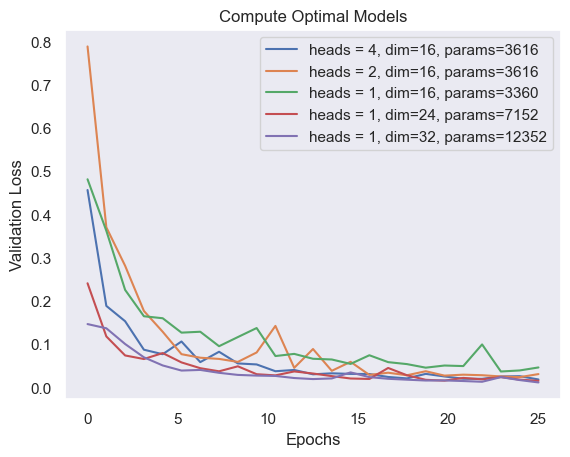

In [34]:
import matplotlib.pyplot as plt
import numpy as np

configs = [
    (16, 4, 4, 64),  # (hidden_size, num_heads, num_layers, batch_size)
    (16, 2, 4, 64),
    (16, 1, 4, 64),
    (24, 1, 4, 64),
    (32, 1, 4, 64),
]

all_results = {}

for hidden_size, num_heads, num_layers, batch_size in configs:
    print(
        f"\nTraining model: hidden_size={hidden_size}, num_heads={num_heads}, num_layers={num_layers}"
    )

    model = load_model_auto(
        MultiheadDecoderTransformer,
        vocab_size=len(decoder_ds_large.idx_to_token),
        hidden_size=hidden_size,
        num_layers=num_layers,
        num_heads=num_heads,
    )

    optimizer = optim.AdamW(model.parameters(), lr=5e-3)
    scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.95)

    results = train(
        model=model,
        dataset=decoder_ds_large,
        num_epochs=NUM_EPOCHS,
        optimizer=optimizer,
        scheduler=scheduler,
        device=device,
        batch_size=batch_size,
    )
    save_model_auto(model)

    parameters = calc_parameters_decoder(model)
    x_points = np.linspace(0, len(results["val_loss"]), len(results["val_loss"]))
    plt.plot(
        x_points,
        results["val_loss"],
        label="heads = {}, dim={}, params={}".format(
            num_heads, hidden_size, parameters
        ),
    )

plt.xlabel("Epochs")
plt.ylabel("Validation Loss")
plt.title("Compute Optimal Models")
plt.grid()
plt.legend()
plt.show()

In [35]:
plt.clf()

<Figure size 640x480 with 0 Axes>

# Part 3: IsoFLOP Profiling and Scaling Laws
In this final section, you'll compare different architectures based on their compute efficiency. You will also determine the optimal number of parameters and tokens for a fixed compute budget.

While this section does not require any additional code from you, **use the output of it to guide your written responses**.

In [ ]:
from utils import (
    plot_scaling_law,
    plot_scaling_law_poly,
    interpolate,
    plot_flops_tokens,
    plot_isoflop,
    plot_flops_params,
)

import numpy as np

## Step 1: Train models, Compare FLOPS vs Validation Loss

We'll inspect the compute efficiency of different models by plotting their validation loss against the number of FLOPs used in training up to that point.

In [37]:
from types_hw2 import TrainerHistDict

In [ ]:
configs = [
    (40, 2, 4, 256),  # (hidden_size, num_heads, num_layers, batch_size)
    (32, 2, 4, 128),
    (24, 2, 4, 64),
    (16, 1, 4, 64),
    (16, 1, 3, 64),
    (12, 1, 3, 64),
    (12, 1, 2, 64),
]

all_results: dict[int, TrainerHistDict] = {}

for hidden_size, num_heads, num_layers, batch_size in configs:
    print(
        f"\nTraining model: hidden_size={hidden_size}, num_heads={num_heads}, num_layers={num_layers}"
    )

    model = load_model_auto(
        MultiheadDecoderTransformer,
        vocab_size=len(decoder_ds_large.idx_to_token),
        hidden_size=hidden_size,
        num_layers=num_layers,
        num_heads=num_heads,
    )

    optimizer = optim.AdamW(model.parameters(), lr=5e-3)
    scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.95)

    results = train(
        model=model,
        dataset=decoder_ds_large,
        num_epochs=NUM_EPOCHS,
        optimizer=optimizer,
        scheduler=scheduler,
        device=device,
        batch_size=batch_size,
    )
    save_model_auto(model)

    parameters = calc_parameters_decoder(model)
    all_results[parameters] = results


Training model: hidden_size=40, num_heads=2, num_layers=4
[INFO] Loading model weights from /Users/Akseldkw/coding/Columbia/COMS4776-Data/data/homework/HW2/MultiheadDecoderTransformer/Model_vocab30_hid40_layers4_heads2.pt onto mps device.
Epoch 1 | Train loss: 1.528885 | Val loss 0.670217
Epoch 2 | Train loss: 0.346934 | Val loss 0.153018
Epoch 3 | Train loss: 0.123261 | Val loss 0.108073
Epoch 4 | Train loss: 0.062645 | Val loss 0.078309
Epoch 5 | Train loss: 0.047663 | Val loss 0.045472
Epoch 6 | Train loss: 0.031922 | Val loss 0.052582
Epoch 7 | Train loss: 0.033140 | Val loss 0.030728
Epoch 8 | Train loss: 0.020986 | Val loss 0.028729
Epoch 9 | Train loss: 0.017214 | Val loss 0.024835
Epoch 10 | Train loss: 0.018561 | Val loss 0.038733
Epoch 11 | Train loss: 0.017493 | Val loss 0.020770
Epoch 12 | Train loss: 0.008237 | Val loss 0.017349
Epoch 13 | Train loss: 0.005149 | Val loss 0.013267
Epoch 14 | Train loss: 0.006774 | Val loss 0.019120
Epoch 15 | Train loss: 0.007481 | Val los

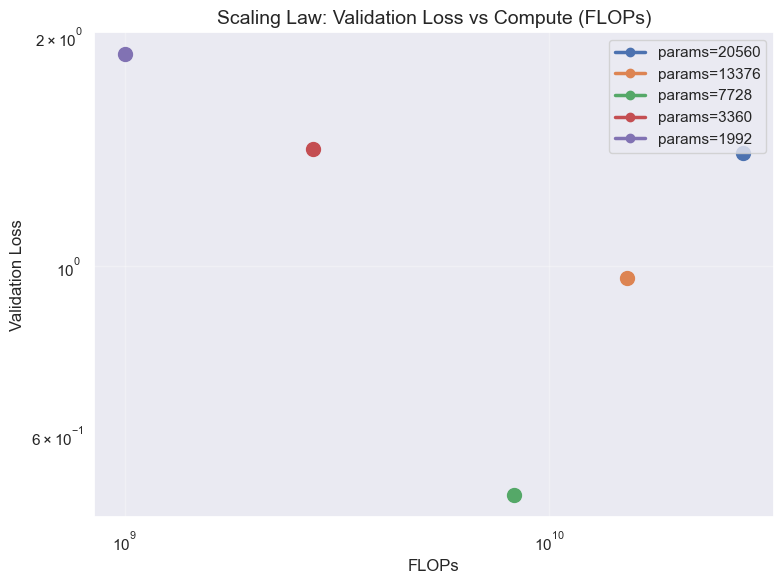

/Users/Akseldkw/Desktop/Columbia/COMS4776/homework/HW2/utils.py:186: RankWarning: Polyfit may be poorly conditioned
  poly_coeffs = np.polyfit(np.log10(flops), np.log10(val_loss), 5)
/Users/Akseldkw/Desktop/Columbia/COMS4776/homework/HW2/utils.py:186: RankWarning: Polyfit may be poorly conditioned
  poly_coeffs = np.polyfit(np.log10(flops), np.log10(val_loss), 5)
/Users/Akseldkw/Desktop/Columbia/COMS4776/homework/HW2/utils.py:186: RankWarning: Polyfit may be poorly conditioned
  poly_coeffs = np.polyfit(np.log10(flops), np.log10(val_loss), 5)
/Users/Akseldkw/Desktop/Columbia/COMS4776/homework/HW2/utils.py:186: RankWarning: Polyfit may be poorly conditioned
  poly_coeffs = np.polyfit(np.log10(flops), np.log10(val_loss), 5)
/Users/Akseldkw/Desktop/Columbia/COMS4776/homework/HW2/utils.py:186: RankWarning: Polyfit may be poorly conditioned
  poly_coeffs = np.polyfit(np.log10(flops), np.log10(val_loss), 5)


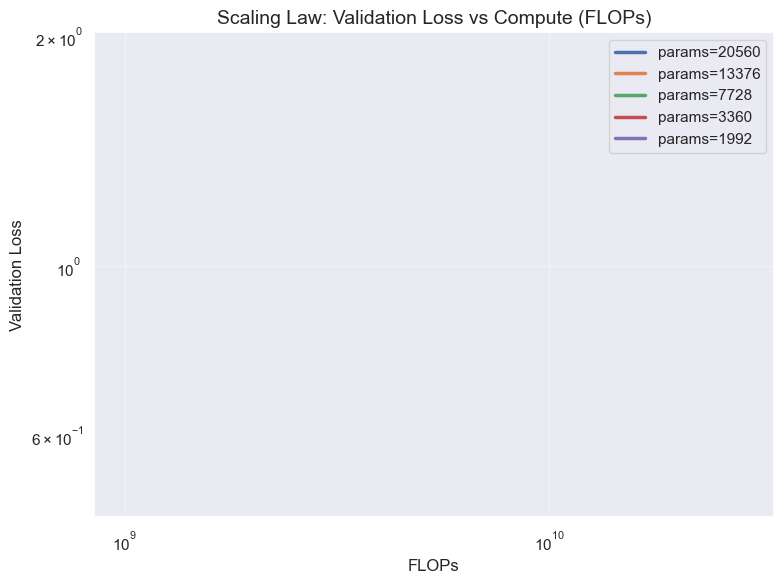

In [ ]:
plot_scaling_law(all_results)

plot_scaling_law_poly(all_results)

## Step 2: Optimal Number of Parameters

Using the previously created training runs, we'll fit quadratic functions to the (parameter count, validation loss) pairs to estimate the optimal number of parameters for a given compute budget. We'll then fit a line to this set of optimal parameters to estimate the optimal number of parameters for a compute budget of 1e15.

In [ ]:
def find_optim_params(params: torch.Tensor, loss: torch.Tensor):
    x = np.array(params.cpu())
    y = np.array(loss.cpu())

    p = np.polyfit(np.log10(x), y, 2)
    optimal_log_params = -(p[1]) / (2 * p[0])
    optimal_params = 10 ** (optimal_log_params)

    return optimal_params


target_flops = [8e9, 16e9, 32e9, 64e9, 128e9]
colors = ["#E41A1C", "#377EB8", "#4DAF4A", "#984EA3", "#FF7F00"]
params_vs_loss = []
optimal_params = []

for target in target_flops:
    parameters = []
    val_loss = []

    for params, results in all_results.items():
        loss = interpolate(results["val_loss"], results["flops"], target, deg=4)

        # interpolate returns None if target is out of range
        if loss != None:
            parameters.append(params)
            val_loss.append(loss)

    sorted_indices = torch.argsort(torch.tensor(parameters)).to(device)
    parameters = torch.tensor(parameters).to(device)[sorted_indices]
    val_loss = torch.tensor(val_loss).to(device)[sorted_indices]
    try:
        optimal_params.append(find_optim_params(parameters, val_loss))
        params_vs_loss.append((parameters.tolist(), val_loss.tolist()))
    except Exception as e:
        print(
            f"{optimal_params=}\n\n{params_vs_loss=}\n\n{parameters=}\n\n{val_loss=}\n\n{target=}"
        )

/var/folders/dj/k5kk5wk90vvcnb_wphpw490r0000gn/T/ipykernel_91624/2694499551.py:2: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  x = np.array(params.cpu())
/var/folders/dj/k5kk5wk90vvcnb_wphpw490r0000gn/T/ipykernel_91624/2694499551.py:3: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  y = np.array(loss.cpu())


8.00 GFlops: Optimal params = 7,701
16.00 GFlops: Optimal params = 7,701
32.00 GFlops: Optimal params = 7,701
64.00 GFlops: Optimal params = 7,701
128.00 GFlops: Optimal params = 7,701


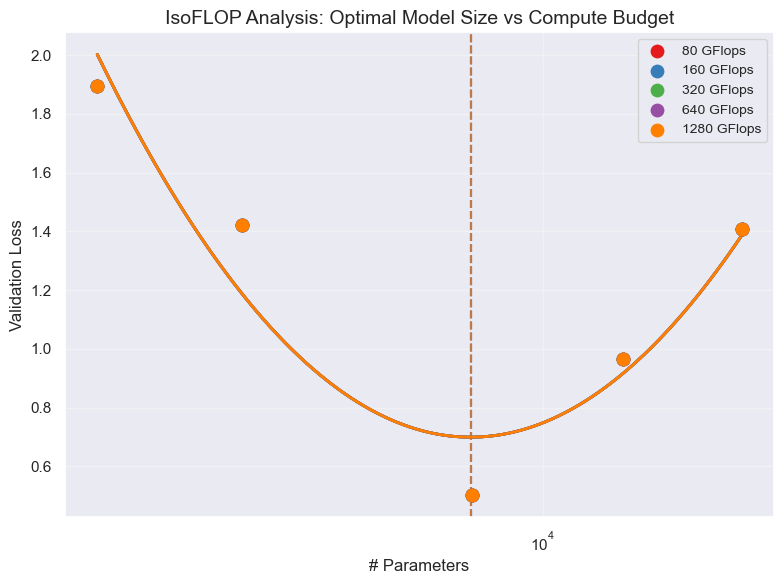

In [ ]:
plot_isoflop(target_flops, colors, params_vs_loss, optimal_params)

y = 2.644567614964774e-16x + 3.886552322415936


/Users/Akseldkw/Desktop/Columbia/COMS4776/homework/HW2/utils.py:282: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="lower left")


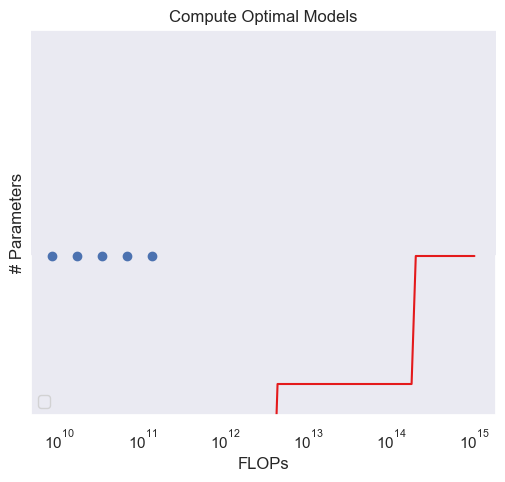

In [ ]:
plot_flops_params(target_flops, optimal_params)

## Step 3: Optimal Number of Tokens

Finally, we'll perform a similar analysis to the previous step, only this time determining the optimal number of tokens for a budget of 1e15 flops.

y = 1.1711656580558287e-15x + 5.26359811181344


/Users/Akseldkw/Desktop/Columbia/COMS4776/homework/HW2/utils.py:323: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="lower left")


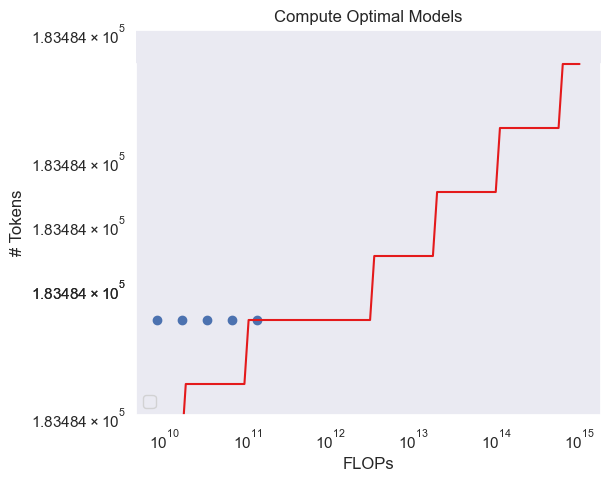

In [ ]:
plot_flops_tokens(target_flops, optimal_params, all_results)